In [1]:
import sqlite3
import pandas as pd

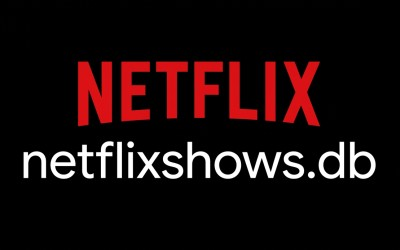

In [2]:
conn = sqlite3.connect('netflixshows.db')

# **check : existing table names in netflixshows.db**

In [3]:
cursor = conn.execute("SELECT name FROM sqlite_master WHERE type='table';")

In [4]:
for row in cursor:
  print(row)

('titles',)
('ratings',)


# **Load all the tables in Pandas Data Frame**

In [5]:
titles = pd.read_sql_query("SELECT * FROM titles",conn)
titles

,show_id,title,type,genre,release_year,country
0,1,Stranger Things,TV Show,Sci-Fi,2016,USA
1,2,Money Heist,TV Show,Crime,2017,Spain
2,3,Wednesday,TV Show,Fantasy,2022,USA
3,4,Extraction,Movie,Action,2020,India
4,5,The Irishman,Movie,Drama,2019,USA
5,6,Dark,TV Show,Sci-Fi,2017,Germany
6,7,Squid Game,TV Show,Thriller,2021,South Korea
7,8,The Gray Man,Movie,Action,2022,USA
8,9,Lupin,TV Show,Crime,2021,France
9,10,Red Notice,Movie,Action,2021,USA


In [6]:
ratings = pd.read_sql_query("SELECT * FROM ratings",conn)
ratings

,rating_id,show_id,imdb_rating,votes
0,1,1,8.7,1200000
1,2,2,8.2,550000
2,3,3,8.1,420000
3,4,4,6.7,250000
4,5,5,7.8,410000
5,6,6,8.7,430000
6,7,7,8.0,710000
7,8,8,6.5,180000
8,9,9,7.5,140000
9,10,10,6.3,320000


# **Understanding the data**

In [7]:
titles.shape

(10, 6)

In [8]:
titles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       10 non-null     int64 
 1   title         10 non-null     object
 2   type          10 non-null     object
 3   genre         10 non-null     object
 4   release_year  10 non-null     int64 
 5   country       10 non-null     object
dtypes: int64(2), object(4)
memory usage: 612.0+ bytes


In [9]:
titles.describe(include='all')

,show_id,title,type,genre,release_year,country
count,10.00000,10,10,10,10.000000,10
unique,NaN,10,2,6,NaN,6
top,NaN,Stranger Things,TV Show,Action,NaN,USA
freq,NaN,1,6,3,NaN,5
mean,5.50000,NaN,NaN,NaN,2019.600000,NaN
std,3.02765,NaN,NaN,NaN,2.221111,NaN
min,1.00000,NaN,NaN,NaN,2016.000000,NaN
25%,3.25000,NaN,NaN,NaN,2017.500000,NaN
50%,5.50000,NaN,NaN,NaN,2020.500000,NaN
75%,7.75000,NaN,NaN,NaN,2021.000000,NaN


In [10]:
titles.isnull().sum()

,0
show_id,0
title,0
type,0
genre,0
release_year,0
country,0


In [11]:
titles.duplicated().sum()

np.int64(0)

### TITLES
### How many shows ? 10

### how many column ? 6

### is there any null values ? no
### is there any duplicated values ? no

In [12]:
ratings.shape

(10, 4)

In [13]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rating_id    10 non-null     int64  
 1   show_id      10 non-null     int64  
 2   imdb_rating  10 non-null     float64
 3   votes        10 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 452.0 bytes


In [14]:
ratings.describe(include='all')

,rating_id,show_id,imdb_rating,votes
count,10.00000,10.00000,10.00000,1.000000e+01
mean,5.50000,5.50000,7.65000,4.610000e+05
std,3.02765,3.02765,0.87718,3.104996e+05
min,1.00000,1.00000,6.30000,1.400000e+05
25%,3.25000,3.25000,6.90000,2.675000e+05
50%,5.50000,5.50000,7.90000,4.150000e+05
75%,7.75000,7.75000,8.17500,5.200000e+05
max,10.00000,10.00000,8.70000,1.200000e+06


In [15]:
ratings.isnull().sum()

,0
rating_id,0
show_id,0
imdb_rating,0
votes,0


In [16]:
ratings.duplicated().sum()

np.int64(0)

### RATINGS
### How many rows ? 10
### How many columns ? 4
### is there any null values ? no
### is there any duplicate values ? no

# **DATA CLEANING**

In [17]:
####### NOT NEEDED

# **EXPLORATIVE DATA ANALYSIS ( EDA )**

In [18]:
titles.head()

,show_id,title,type,genre,release_year,country
0,1,Stranger Things,TV Show,Sci-Fi,2016,USA
1,2,Money Heist,TV Show,Crime,2017,Spain
2,3,Wednesday,TV Show,Fantasy,2022,USA
3,4,Extraction,Movie,Action,2020,India
4,5,The Irishman,Movie,Drama,2019,USA


### 1) How many shows ? ANSWER : 10
### Total records = 10, so all 10 records are unique titles

In [19]:
titles['title'].value_counts()

,count
title,
Stranger Things,1
Money Heist,1
Wednesday,1
Extraction,1
The Irishman,1
Dark,1
Squid Game,1
The Gray Man,1
Lupin,1


### 2) How many movies vs tvshows ?
### ANSWER : tvshow-6  movie-4

In [20]:
len(titles[titles['type']=='TV Show'])

6

In [21]:
len(titles[titles['type']=='Movie'])

4

### 3) Which genre appears the most? ANSWER : Action (3 times)

In [22]:
titles['genre'].value_counts()

,count
genre,
Action,3
Sci-Fi,2
Crime,2
Fantasy,1
Drama,1
Thriller,1


### 4) What is the oldest content ? 2016 -- check below show names
### What is the newest content ? 2022 -- check below show names

In [23]:
titles[titles['release_year']==titles['release_year'].max()]

,show_id,title,type,genre,release_year,country
2,3,Wednesday,TV Show,Fantasy,2022,USA
7,8,The Gray Man,Movie,Action,2022,USA


In [24]:
titles[titles['release_year']==titles['release_year'].min()]

,show_id,title,type,genre,release_year,country
0,1,Stranger Things,TV Show,Sci-Fi,2016,USA


### 5) Which country produced more ? ANSWER : USA (5)

In [25]:
titles['country'].value_counts()

,count
country,
USA,5
Spain,1
India,1
Germany,1
South Korea,1
France,1


In [26]:
ratings.head()

,rating_id,show_id,imdb_rating,votes
0,1,1,8.7,1200000
1,2,2,8.2,550000
2,3,3,8.1,420000
3,4,4,6.7,250000
4,5,5,7.8,410000


### 1) How man ratings ? ANSWER : 10

In [27]:
ratings.shape[0]

10

### 2) titles table JOIN ratings table

In [28]:
reviews = pd.read_sql_query("""
SELECT *
FROM titles LEFT JOIN ratings
ON titles.show_id=ratings.show_id;
""",conn)

In [29]:
reviews

,show_id,title,type,genre,release_year,country,rating_id,show_id,imdb_rating,votes
0,1,Stranger Things,TV Show,Sci-Fi,2016,USA,1,1,8.7,1200000
1,2,Money Heist,TV Show,Crime,2017,Spain,2,2,8.2,550000
2,3,Wednesday,TV Show,Fantasy,2022,USA,3,3,8.1,420000
3,4,Extraction,Movie,Action,2020,India,4,4,6.7,250000
4,5,The Irishman,Movie,Drama,2019,USA,5,5,7.8,410000
5,6,Dark,TV Show,Sci-Fi,2017,Germany,6,6,8.7,430000
6,7,Squid Game,TV Show,Thriller,2021,South Korea,7,7,8.0,710000
7,8,The Gray Man,Movie,Action,2022,USA,8,8,6.5,180000
8,9,Lupin,TV Show,Crime,2021,France,9,9,7.5,140000
9,10,Red Notice,Movie,Action,2021,USA,10,10,6.3,320000


### 3) Show with highest IMDB rating ? ANSWER : Stranger Things(8.7), Dark(8.7)
### Show with lowest IMDB rating ? ANSWER : Red Notice(6.3)

In [30]:
reviews[reviews['imdb_rating']==reviews['imdb_rating'].max()]

,show_id,title,type,genre,release_year,country,rating_id,show_id,imdb_rating,votes
0,1,Stranger Things,TV Show,Sci-Fi,2016,USA,1,1,8.7,1200000
5,6,Dark,TV Show,Sci-Fi,2017,Germany,6,6,8.7,430000


In [31]:
reviews[reviews['imdb_rating']==reviews['imdb_rating'].min()]

,show_id,title,type,genre,release_year,country,rating_id,show_id,imdb_rating,votes
9,10,Red Notice,Movie,Action,2021,USA,10,10,6.3,320000


### 4) Which show has highest no of votes ? ANSWER : Stranger Things(12,00,000)
### Which show has lowest no of votes ? ANSWER : Lupin(1,14,000)

In [32]:
reviews[reviews['votes']==reviews['votes'].max()]

,show_id,title,type,genre,release_year,country,rating_id,show_id,imdb_rating,votes
0,1,Stranger Things,TV Show,Sci-Fi,2016,USA,1,1,8.7,1200000


In [33]:
reviews[reviews['votes']==reviews['votes'].min()]

,show_id,title,type,genre,release_year,country,rating_id,show_id,imdb_rating,votes
8,9,Lupin,TV Show,Crime,2021,France,9,9,7.5,140000


# **VISUALIZATION**

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
reviews.head()

,show_id,title,type,genre,release_year,country,rating_id,show_id,imdb_rating,votes
0,1,Stranger Things,TV Show,Sci-Fi,2016,USA,1,1,8.7,1200000
1,2,Money Heist,TV Show,Crime,2017,Spain,2,2,8.2,550000
2,3,Wednesday,TV Show,Fantasy,2022,USA,3,3,8.1,420000
3,4,Extraction,Movie,Action,2020,India,4,4,6.7,250000
4,5,The Irishman,Movie,Drama,2019,USA,5,5,7.8,410000


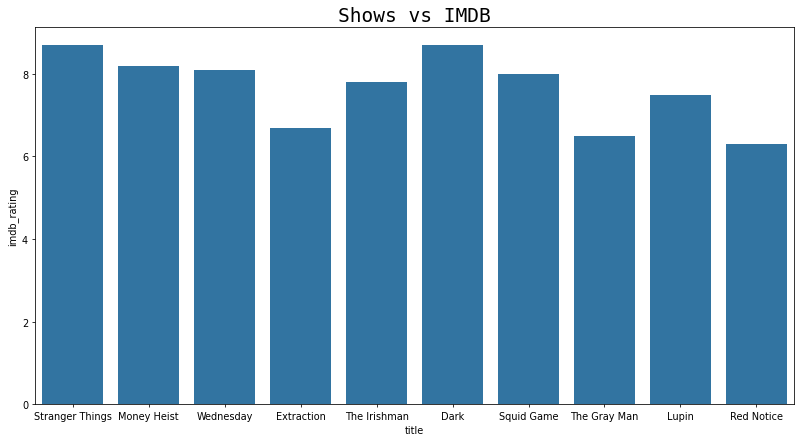

In [36]:
plt.figure(figsize=(14,7),dpi=70)
sns.barplot(data=reviews,x='title',y='imdb_rating')
plt.title('Shows vs IMDB',fontdict={'fontname':'monospace','fontsize':20})
plt.show()

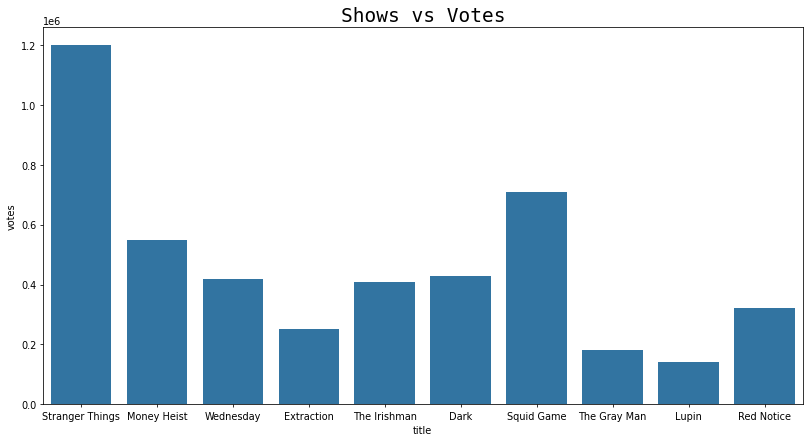

In [37]:
plt.figure(figsize=(14,7),dpi=70)
sns.barplot(data=reviews,x='title',y='votes')
plt.title('Shows vs Votes',fontdict={'fontname':'monospace','fontsize':20})
plt.show()

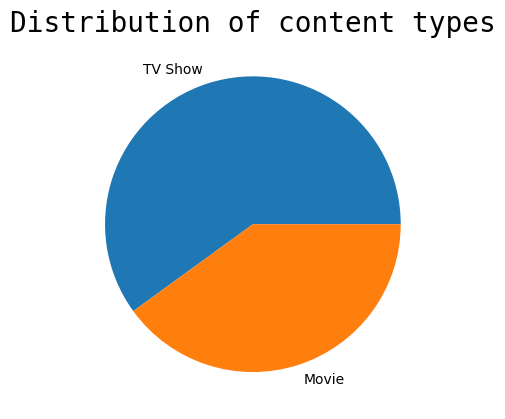

In [38]:
typecounts = reviews['type'].value_counts()
plt.pie(typecounts,labels=typecounts.index)
plt.title('Distribution of content types',fontdict={'fontname':'monospace','fontsize':20})
plt.show()

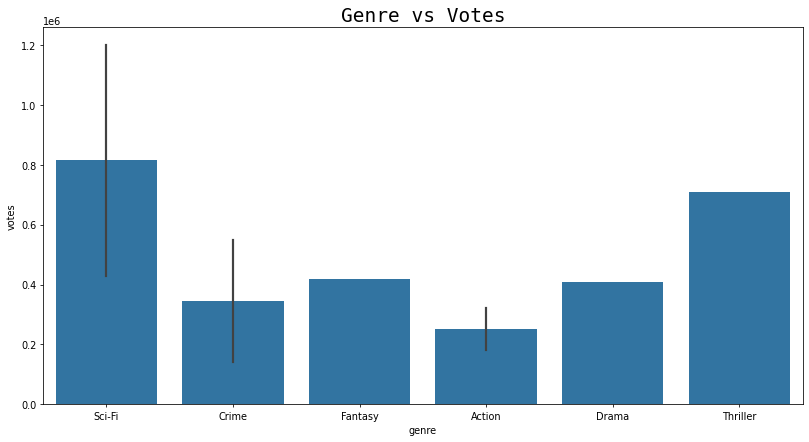

In [39]:
plt.figure(figsize=(14,7),dpi=70)
sns.barplot(data=reviews,x='genre',y='votes')
plt.title('Genre vs Votes',fontdict={'fontname':'monospace','fontsize':20})
plt.show()

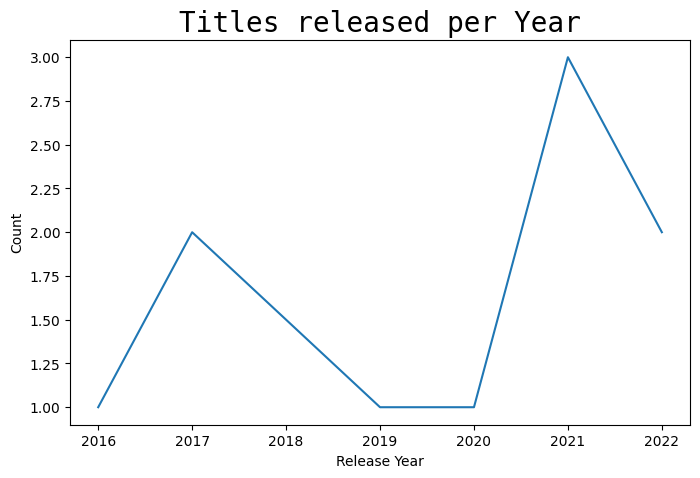

In [40]:
yearcounts = reviews['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,5),dpi=100)
sns.lineplot(x=yearcounts.index,y=yearcounts.values)
plt.title('Titles released per Year',fontdict={'fontname':'monospace','fontsize':20})
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()

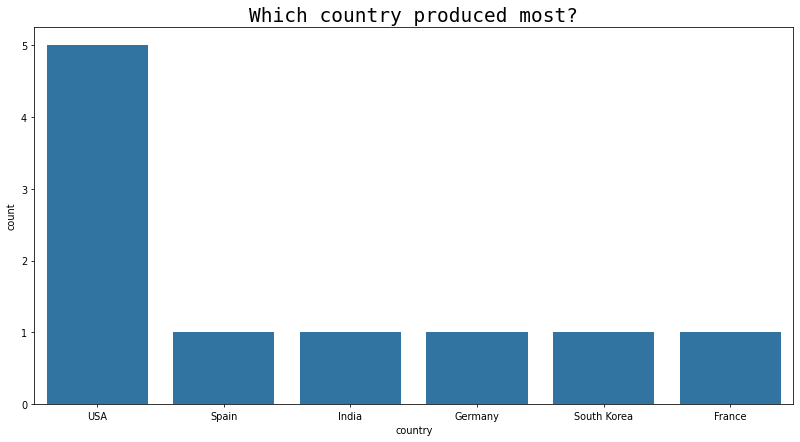

In [41]:
plt.figure(figsize=(14,7),dpi=70)
sns.countplot(data=reviews,x='country')
plt.title('Which country produced most?',fontdict={'fontname':'monospace','fontsize':20})
plt.show()

# **INSIGHTS**

### **IMDB Rating and Votes Insights**

*   **Highest IMDB Ratings**: 'Stranger Things' and 'Dark' share the top spot with an impressive IMDB rating of 8.7.
*   **Lowest IMDB Rating**: 'Red Notice' recorded the lowest IMDB rating at 6.3.
*   **Most Voted Content**: 'Stranger Things' leads significantly in audience engagement with 1,200,000 votes.
*   **Least Voted Content**: 'Lupin' received the fewest votes, totaling 140,000.
*   **Which Country Produced most**: USA

